<a href="https://colab.research.google.com/github/niradaa-art/project_BP_group8/blob/main/longtum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
url = "https://raw.githubusercontent.com/niradaa-art/project_BP_group8/main/raw_data/provincial_budget.csv"
df = pd.read_csv(url,sep="|", encoding='utf-8')
df.columns


Index(['fy', 'changwad_area_name', 'min_name', 'agc_name', 'plan_name',
       'output_name', 'objc', 'budget'],
      dtype='object')

In [ ]:
df['budget'] = pd.to_numeric(df['budget'],errors='coerce')

In [ ]:
df.head()

,fy,changwad_area_name,min_name,agc_name,plan_name,output_name,objc,budget
0,66,ส่วนกลาง,งบกลาง,งบกลาง,แผนงานยุทธศาสตร์พัฒนาระบบการเตรียมพร้อมแห่งชาต...,รายจ่ายงบกลาง : ค่าใช้จ่ายชดใช้เงินทดรองราชการ...,งบรายจ่ายอื่น,2000000000
1,66,ส่วนกลาง,งบกลาง,งบกลาง,แผนงานพื้นฐานด้านความมั่นคง,รายจ่ายงบกลาง : ค่าใช้จ่ายเกี่ยวกับการเสด็จพระ...,งบดำเนินงาน,800000000
2,66,ส่วนกลาง,งบกลาง,งบกลาง,แผนงานยุทธศาสตร์เสริมสร้างพลังทางสังคม,รายจ่ายงบกลาง : ค่าใช้จ่ายตามโครงการอันเนื่องม...,งบรายจ่ายอื่น,300000000
3,66,ส่วนกลาง,งบกลาง,งบกลาง,แผนงานยุทธศาสตร์เสริมสร้างพลังทางสังคม,รายจ่ายงบกลาง : ค่าใช้จ่ายตามโครงการอันเนื่องม...,งบลงทุน,2000000000
4,66,ส่วนกลาง,งบกลาง,งบกลาง,แผนงานยุทธศาสตร์สร้างหลักประกันทางสังคม,รายจ่ายงบกลาง : ค่าใช้จ่ายในการรักษาพยาบาลข้าร...,งบดำเนินงาน,76000000000


Q1 : จังหวัดใดได้รับการจัดสรรงบประมาณสูงสุด?
จังหวัดที่ได้รับงบประมาณสูงสุด คือ กรุงเทพมหานคร
งบประมาณ = 1,749,225,796,960.00 บาท
หรือประมาณ 1,749,225.80 ล้านบาท


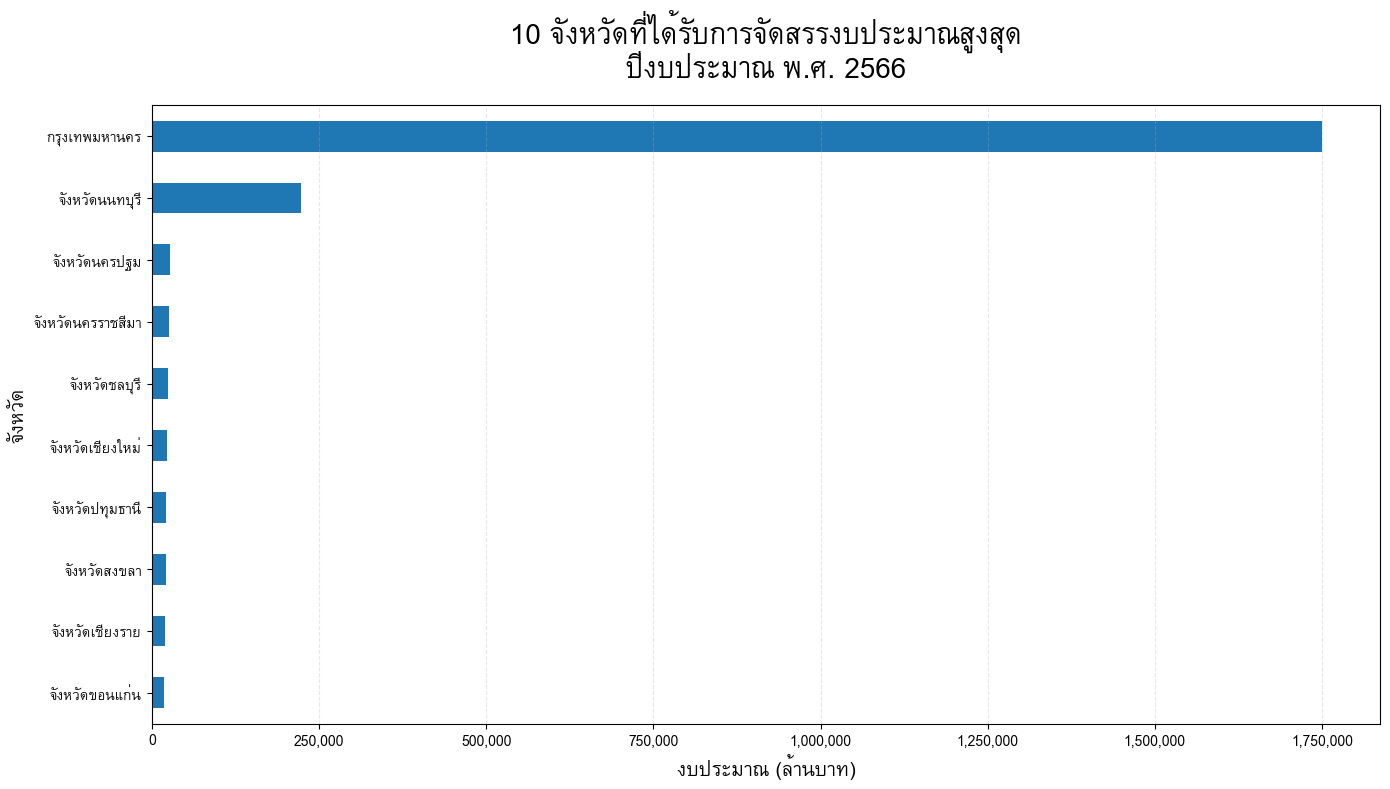

,จังหวัด,งบประมาณ (บาท),งบประมาณ (ล้านบาท)
0,กรุงเทพมหานคร,1749225796960,1749225.80
1,จังหวัดนนทบุรี,223509614240,223509.61
2,จังหวัดนครปฐม,27345154550,27345.15
3,จังหวัดนครราชสีมา,25644195365,25644.20
4,จังหวัดชลบุรี,23775421300,23775.42
5,จังหวัดเชียงใหม่,22290356390,22290.36
6,จังหวัดปทุมธานี,21701339980,21701.34
7,จังหวัดสงขลา,21119513630,21119.51
8,จังหวัดเชียงราย,18966951980,18966.95
9,จังหวัดขอนแก่น,18667361820,18667.36


In [ ]:
# ============================================================
# Q1 : จังหวัดใดได้รับการจัดสรรงบประมาณสูงสุด?
# ============================================================

province_budget = (
    df.groupby("changwad_area_name")["budget"]
      .sum()
      .sort_values(ascending=False)
)


# ------------------------------------------------------------
# ตัด "ส่วนกลาง" ออก
# ------------------------------------------------------------

province_budget = province_budget[
    province_budget.index.astype(str).str.strip() != "ส่วนกลาง"
]


# ------------------------------------------------------------
# Top 10 จังหวัด
# ------------------------------------------------------------

top10_provinces = province_budget.head(10)


# ============================================================
# แสดงคำตอบ
# ============================================================

highest_province = province_budget.idxmax()
highest_budget = province_budget.max()

print("=" * 60)
print("Q1 : จังหวัดใดได้รับการจัดสรรงบประมาณสูงสุด?")
print("=" * 60)

print(
    f"จังหวัดที่ได้รับงบประมาณสูงสุด คือ {highest_province}"
)

print(
    f"งบประมาณ = {highest_budget:,.2f} บาท"
)

print(
    f"หรือประมาณ {highest_budget/1_000_000:,.2f} ล้านบาท"
)


# ============================================================
# กราฟ
# ============================================================

fig, ax = plt.subplots(figsize=(14, 8))

top10_provinces.sort_values().plot(
    kind="barh",
    ax=ax
)

ax.set_title(
    "10 จังหวัดที่ได้รับการจัดสรรงบประมาณสูงสุด\n"
    "ปีงบประมาณ พ.ศ. 2566",
    fontproperties=garuda_font,
    fontsize=20,
    pad=20
)

ax.set_xlabel(
    "งบประมาณ (ล้านบาท)",
    fontproperties=garuda_font,
    fontsize=14
)

ax.set_ylabel(
    "จังหวัด",
    fontproperties=garuda_font,
    fontsize=14
)


# ------------------------------------------------------------
# แกน Y ภาษาไทย
# ------------------------------------------------------------

for label in ax.get_yticklabels():
    label.set_fontproperties(garuda_font)


# ------------------------------------------------------------
# แกน X ตัวเลข
# ------------------------------------------------------------

ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda x, pos: f"{x/1_000_000:,.0f}"
    )
)

for label in ax.get_xticklabels():
    label.set_fontproperties(garuda_font)


ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# ตาราง
# ============================================================

q1_table = top10_provinces.reset_index()

q1_table.columns = [
    "จังหวัด",
    "งบประมาณ (บาท)"
]

q1_table["งบประมาณ (ล้านบาท)"] = (
    q1_table["งบประมาณ (บาท)"] / 1_000_000
).round(2)

display(q1_table)

Q2 : กระทรวงใดได้รับการจัดสรรงบประมาณสูงสุด?
หน่วยงานที่ได้รับงบประมาณสูงสุด คือ งบกลาง
งบประมาณ = 590,470,000,000.00 บาท
หรือประมาณ 590,470.00 ล้านบาท


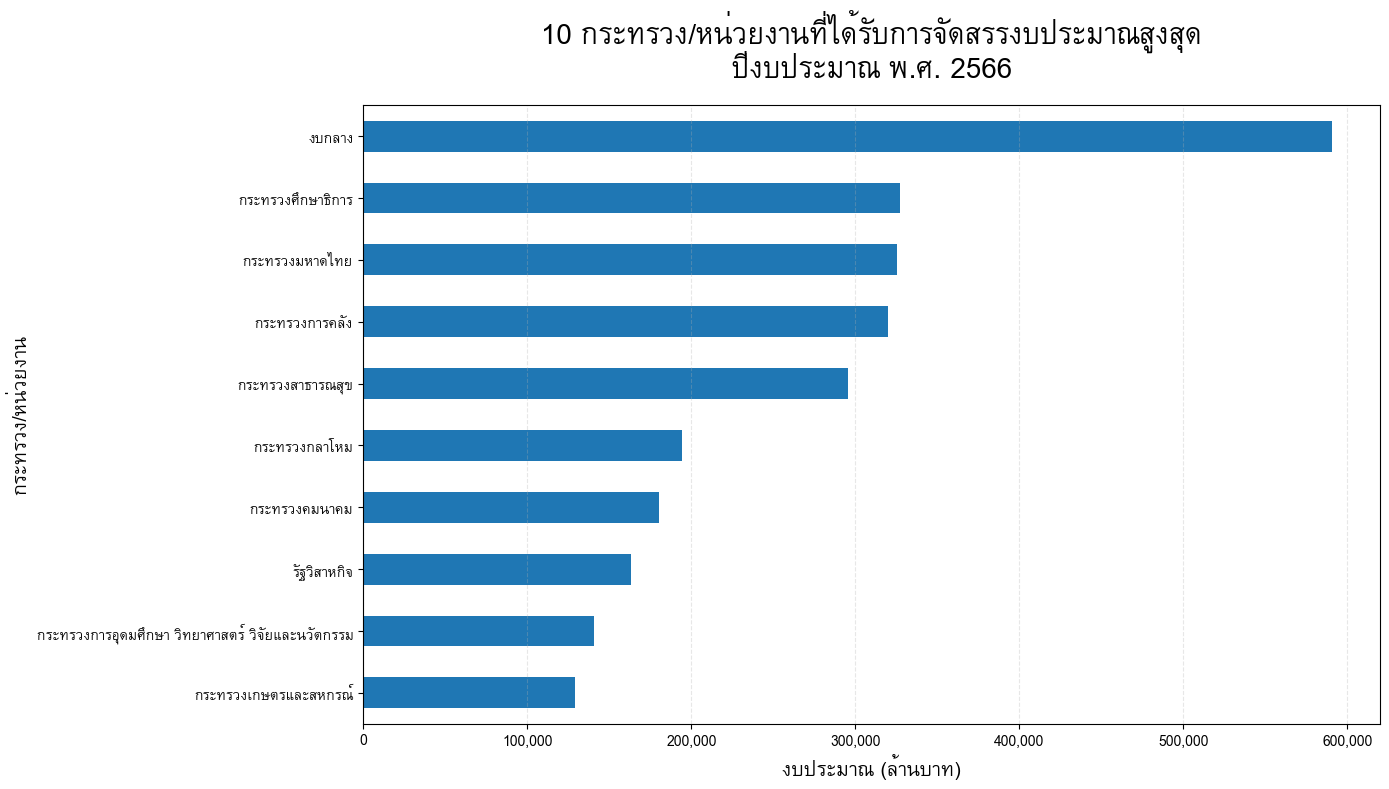

,กระทรวง/หน่วยงาน,งบประมาณ (บาท),งบประมาณ (ล้านบาท)
0,งบกลาง,590470000000,590470.00
1,กระทรวงศึกษาธิการ,327369786400,327369.79
2,กระทรวงมหาดไทย,325708194300,325708.19
3,กระทรวงการคลัง,320089342900,320089.34
4,กระทรวงสาธารณสุข,295662099100,295662.10
5,กระทรวงกลาโหม,194570028200,194570.03
6,กระทรวงคมนาคม,180312920400,180312.92
7,รัฐวิสาหกิจ,162919257800,162919.26
8,กระทรวงการอุดมศึกษา วิทยาศาสตร์ วิจัยและนวัตกรรม,140890397900,140890.40
9,กระทรวงเกษตรและสหกรณ์,129168558100,129168.56


In [ ]:
# ============================================================
# Q2 : กระทรวงใดได้รับการจัดสรรงบประมาณสูงสุด?
# ============================================================

ministry_budget = (
    df.groupby("min_name")["budget"]
      .sum()
      .sort_values(ascending=False)
)


# ------------------------------------------------------------
# Top 10
# ------------------------------------------------------------

top10_ministry = ministry_budget.head(10)


# ============================================================
# คำตอบ
# ============================================================

highest_ministry = ministry_budget.idxmax()
highest_ministry_budget = ministry_budget.max()

print("=" * 60)
print("Q2 : กระทรวงใดได้รับการจัดสรรงบประมาณสูงสุด?")
print("=" * 60)

print(
    f"หน่วยงานที่ได้รับงบประมาณสูงสุด คือ {highest_ministry}"
)

print(
    f"งบประมาณ = {highest_ministry_budget:,.2f} บาท"
)

print(
    f"หรือประมาณ {highest_ministry_budget/1_000_000:,.2f} ล้านบาท"
)


# ============================================================
# กราฟ
# ============================================================

fig, ax = plt.subplots(figsize=(14, 8))

top10_ministry.sort_values().plot(
    kind="barh",
    ax=ax
)

ax.set_title(
    "10 กระทรวง/หน่วยงานที่ได้รับการจัดสรรงบประมาณสูงสุด\n"
    "ปีงบประมาณ พ.ศ. 2566",
    fontproperties=garuda_font,
    fontsize=20,
    pad=20
)

ax.set_xlabel(
    "งบประมาณ (ล้านบาท)",
    fontproperties=garuda_font,
    fontsize=14
)

ax.set_ylabel(
    "กระทรวง/หน่วยงาน",
    fontproperties=garuda_font,
    fontsize=14
)


# ------------------------------------------------------------
# Font แกน
# ------------------------------------------------------------

for label in ax.get_yticklabels():
    label.set_fontproperties(garuda_font)

for label in ax.get_xticklabels():
    label.set_fontproperties(garuda_font)


# ------------------------------------------------------------
# ตัวเลขแกน X
# ------------------------------------------------------------

ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda x, pos: f"{x/1_000_000:,.0f}"
    )
)


ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# ตาราง
# ============================================================

q2_table = top10_ministry.reset_index()

q2_table.columns = [
    "กระทรวง/หน่วยงาน",
    "งบประมาณ (บาท)"
]

q2_table["งบประมาณ (ล้านบาท)"] = (
    q2_table["งบประมาณ (บาท)"] / 1_000_000
).round(2)

display(q2_table)

Q3 : แผนงานใดได้รับการจัดสรรงบประมาณสูงสุด?
แผนงานที่ได้รับงบประมาณสูงสุด คือ แผนงานบุคลากรภาครัฐ
งบประมาณ = 768,108,525,300.00 บาท
หรือประมาณ 768,108.53 ล้านบาท


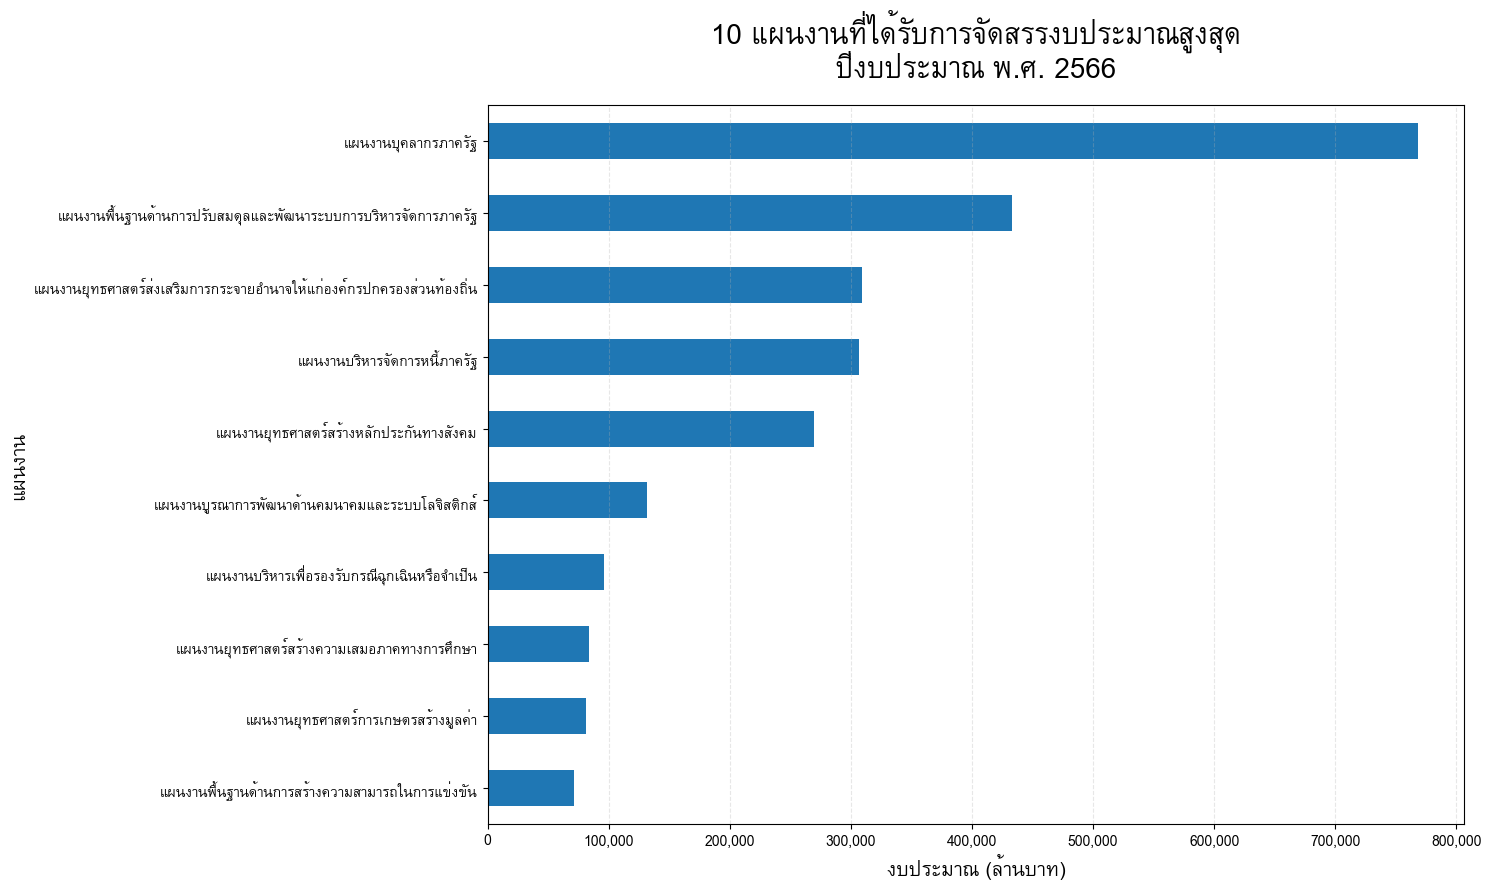

,แผนงาน,งบประมาณ (บาท),งบประมาณ (ล้านบาท)
0,แผนงานบุคลากรภาครัฐ,768108525300,768108.53
1,แผนงานพื้นฐานด้านการปรับสมดุลและพัฒนาระบบการบร...,432674931000,432674.93
2,แผนงานยุทธศาสตร์ส่งเสริมการกระจายอำนาจให้แก่อง...,309461350500,309461.35
3,แผนงานบริหารจัดการหนี้ภาครัฐ,306617963200,306617.96
4,แผนงานยุทธศาสตร์สร้างหลักประกันทางสังคม,269459682900,269459.68
5,แผนงานบูรณาการพัฒนาด้านคมนาคมและระบบโลจิสติกส์,131286432700,131286.43
6,แผนงานบริหารเพื่อรองรับกรณีฉุกเฉินหรือจำเป็น,95900000000,95900.00
7,แผนงานยุทธศาสตร์สร้างความเสมอภาคทางการศึกษา,83508659900,83508.66
8,แผนงานยุทธศาสตร์การเกษตรสร้างมูลค่า,81117946200,81117.95
9,แผนงานพื้นฐานด้านการสร้างความสามารถในการแข่งขัน,71643249500,71643.25


In [ ]:
# ============================================================
# Q3 : แผนงานใดได้รับการจัดสรรงบประมาณสูงสุด?
# ============================================================

plan_budget = (
    df.groupby("plan_name")["budget"]
      .sum()
      .sort_values(ascending=False)
)


# ------------------------------------------------------------
# Top 10
# ------------------------------------------------------------

top10_plans = plan_budget.head(10)


# ============================================================
# คำตอบ
# ============================================================

highest_plan = plan_budget.idxmax()
highest_plan_budget = plan_budget.max()

print("=" * 60)
print("Q3 : แผนงานใดได้รับการจัดสรรงบประมาณสูงสุด?")
print("=" * 60)

print(
    f"แผนงานที่ได้รับงบประมาณสูงสุด คือ {highest_plan}"
)

print(
    f"งบประมาณ = {highest_plan_budget:,.2f} บาท"
)

print(
    f"หรือประมาณ {highest_plan_budget/1_000_000:,.2f} ล้านบาท"
)


# ============================================================
# กราฟ
# ============================================================

fig, ax = plt.subplots(figsize=(15, 9))

top10_plans.sort_values().plot(
    kind="barh",
    ax=ax
)

ax.set_title(
    "10 แผนงานที่ได้รับการจัดสรรงบประมาณสูงสุด\n"
    "ปีงบประมาณ พ.ศ. 2566",
    fontproperties=garuda_font,
    fontsize=20,
    pad=20
)

ax.set_xlabel(
    "งบประมาณ (ล้านบาท)",
    fontproperties=garuda_font,
    fontsize=14
)

ax.set_ylabel(
    "แผนงาน",
    fontproperties=garuda_font,
    fontsize=14
)


# ------------------------------------------------------------
# Font
# ------------------------------------------------------------

for label in ax.get_yticklabels():
    label.set_fontproperties(garuda_font)

for label in ax.get_xticklabels():
    label.set_fontproperties(garuda_font)


# ------------------------------------------------------------
# ตัวเลข
# ------------------------------------------------------------

ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda x, pos: f"{x/1_000_000:,.0f}"
    )
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# ตาราง
# ============================================================

q3_table = top10_plans.reset_index()

q3_table.columns = [
    "แผนงาน",
    "งบประมาณ (บาท)"
]

q3_table["งบประมาณ (ล้านบาท)"] = (
    q3_table["งบประมาณ (บาท)"] / 1_000_000
).round(2)

display(q3_table)

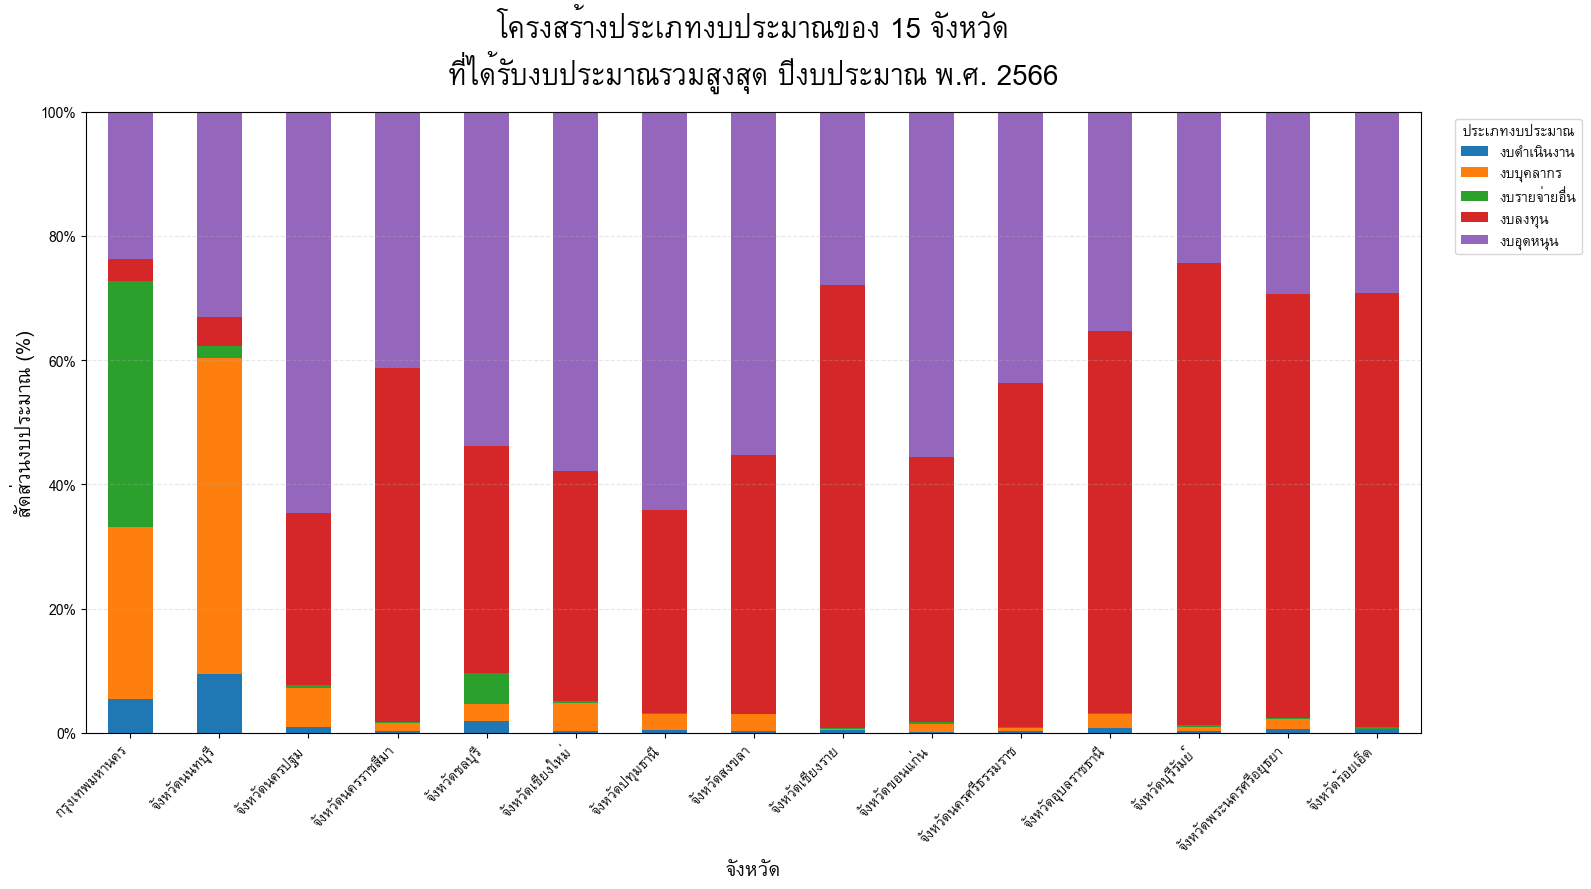

objc,งบดำเนินงาน,งบบุคลากร,งบรายจ่ายอื่น,งบลงทุน,งบอุดหนุน
changwad_area_name,,,,,
กรุงเทพมหานคร,5.49,27.60,39.58,3.63,23.70
จังหวัดนนทบุรี,9.49,50.84,1.94,4.60,33.13
จังหวัดนครปฐม,0.95,6.37,0.36,27.80,64.53
จังหวัดนครราชสีมา,0.27,1.32,0.10,57.03,41.28
จังหวัดชลบุรี,1.90,2.80,4.94,36.60,53.75
จังหวัดเชียงใหม่,0.38,4.49,0.32,36.98,57.82
จังหวัดปทุมธานี,0.42,2.66,0.07,32.77,64.08
จังหวัดสงขลา,0.28,2.74,0.06,41.73,55.19
จังหวัดเชียงราย,0.40,0.27,0.11,71.34,27.87


In [ ]:
# ============================================================
# Q4 : โครงสร้างการจัดสรรงบประมาณของแต่ละจังหวัด
# ============================================================

# ------------------------------------------------------------
# ตัด "ส่วนกลาง"
# ------------------------------------------------------------

province_df = df[
    df["changwad_area_name"].astype(str).str.strip() != "ส่วนกลาง"
].copy()


# ------------------------------------------------------------
# จังหวัด x ประเภทงบประมาณ
# ------------------------------------------------------------

province_type = (
    province_df
    .groupby(
        ["changwad_area_name", "objc"]
    )["budget"]
    .sum()
    .unstack(fill_value=0)
)


# ------------------------------------------------------------
# รวมงบประมาณแต่ละจังหวัด
# ------------------------------------------------------------

province_total = (
    province_type
    .sum(axis=1)
    .sort_values(ascending=False)
)


# ------------------------------------------------------------
# เลือก 15 จังหวัดงบประมาณสูงสุด
# ------------------------------------------------------------

top15_provinces = province_total.head(15).index

top15_type = province_type.loc[
    top15_provinces
]


# ------------------------------------------------------------
# แปลงเป็นเปอร์เซ็นต์
# ------------------------------------------------------------

top15_percent = (
    top15_type
    .div(
        top15_type.sum(axis=1),
        axis=0
    )
    * 100
)


# ============================================================
# กราฟ
# ============================================================

fig, ax = plt.subplots(figsize=(16, 9))

top15_percent.plot(
    kind="bar",
    stacked=True,
    ax=ax
)


ax.set_title(
    "โครงสร้างประเภทงบประมาณของ 15 จังหวัด\n"
    "ที่ได้รับงบประมาณรวมสูงสุด ปีงบประมาณ พ.ศ. 2566",
    fontproperties=garuda_font,
    fontsize=20,
    pad=20
)

ax.set_xlabel(
    "จังหวัด",
    fontproperties=garuda_font,
    fontsize=14
)

ax.set_ylabel(
    "สัดส่วนงบประมาณ (%)",
    fontproperties=garuda_font,
    fontsize=14
)


# ------------------------------------------------------------
# Font แกน
# ------------------------------------------------------------

for label in ax.get_xticklabels():
    label.set_fontproperties(garuda_font)
    label.set_rotation(45)
    label.set_ha("right")

for label in ax.get_yticklabels():
    label.set_fontproperties(garuda_font)


# ------------------------------------------------------------
# Percentage
# ------------------------------------------------------------

ax.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)

ax.set_ylim(0, 100)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

legend = ax.legend(
    title="ประเภทงบประมาณ",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

legend.get_title().set_fontproperties(garuda_font)

for text in legend.get_texts():
    text.set_fontproperties(garuda_font)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# ตารางสัดส่วน
# ============================================================

display(
    top15_percent.round(2)
)